# BBC Projet - Prédiction Des Protéines Membranaires

- Professeur: Xavier Brochet (<a href="mailto:xavier.brochet@heig-vd.ch">xavier.brochet@heig-vd.ch</a>)
- Assistant: Thibault Schowing (<a href="mailto:thibault.schowing@heig-vd.ch">thibault.schowing@heig-vd.ch</a>)

Date: Juin 2026

Kilian Froidevaux & Basile Buxtorf


**Objectif** : Concevoir une approche permettant de prédire si une protéine humaine est ou non localisée au niveau de la membrane cellulaire.

**Méthode retenue** : Modèles de Markov Cachés (HMM) entraînés sur des séquences protéiques encodées, en comparaison avec des approches existantes (DeepTMHMM).

**Auteurs** : Kilian Froidevaux & Basile Buxtorf  


---
## 1. Revue bibliographique Résumé

### 1.1 Structure et fonctions des protéines membranaires

Les protéines membranaires sont classées selon leur association avec la bicouche lipidique :
- **Intégrales (intrinsèques)** : ne peuvent être extraites sans détruire la membrane ; incluent les protéines transmembranaires (alpha-hélicoïdales et tonneaux bêta) et les protéines associées à un seul feuillet.
- **Périphériques (extrinsèques)** : liées à la surface par des interactions ioniques ou hydrogène.
- **Ancrées aux lipides** : attachées de manière covalente à des molécules lipidiques.

**Motifs structuraux** :
- **Faisceaux alpha-hélicoïdaux** (~20–25 résidus non polaires) : stabilisés par des liaisons hydrogène intramoléculaires ; les chaînes latérales hydrophobes interagissent avec les acyles lipidiques. Exemple : aquaporine.
- **Tonneaux bêta** : structure cylindrique où les chaînes latérales non polaires font face aux lipides et le squelette polypeptidique forme des liaisons hydrogène à l'intérieur. Exemple : OmpG.

**Rôles fonctionnels** : transport (canaux, pompes), transduction du signal (GPCR, RTK), activité enzymatique, et rôles structurels/adhésifs.

### 1.2 Intérêt biologique et médical

Les protéines membranaires représentent **25 à 30 % des gènes codants** mais plus de **50 % des cibles thérapeutiques actuelles**. Leur position à la surface cellulaire les rend accessibles aux médicaments.

- **GPCR** : ~34 % des médicaments FDA approuvés les ciblent.
- **Canaux ioniques** : impliqués dans l'épilepsie, arythmies, douleur chronique.
- **Transporteurs** : modulation des concentrations de chimiothérapeutiques et résistance aux médicaments.

Leur caractère hydrophobe rend leur étude expérimentale difficile, ce qui justifie le développement d'outils de prédiction computationnels.

### 1.3 Approches de prédiction existantes

| Méthode | Année | Approche | Caractéristique clé | Précision |
|---------|-------|----------|---------------------|-----------|
| Kyte-Doolittle | 1982 | Échelle d'hydrophobicité | Fenêtre glissante | Faible (premier benchmark) |
| TMHMM | 2001 | HMM | Topologie à l'échelle du génome | 97–98 % hélices ; >99 % discrimination |
| Phobius | 2004 | HMM | Peptide signal + TM conjoints | Réduction significative des erreurs croisées |
| PolyPhobius | ~2007 | HMM + homologie | Alignements multiples (MSA) | 74,7 % topologie |
| PHDhtm | 1995 | Réseaux de neurones | Profils évolutifs | Amélioration vs séquence unique |
| HNN (PRED-TMBB2, HMM-TM) | 2021 | HMM + NN | Architecture hybride | Surpasse HMM classiques |
| AlphaFold2/3 | 2021/2024 | Deep learning (Transformers) | Structure 3D de bout en bout | Excellente (solubles) ; limitée (membranaires) |

Les HMM restent une référence robuste pour la prédiction de topologie membranaire grâce à leur capacité à modéliser les transitions entre états structuraux le long de la séquence.

---
## 2. Stratégie méthodologique

### 2.1 Choix de l'approche

Nous retenons une approche par **Modèles de Markov Cachés (HMM)** pour la classification binaire (membranaire vs non-membranaire), motivée par les arguments suivants :

1. **Données disponibles** : UniProtKB/Swiss-Prot fournit des annotations curées expérimentalement pour des milliers de protéines humaines (mots-clés `KW-0812`, `KW-1003`, `KW-0963`, `KW-0539`).
2. **Outils** : `hmmlearn` offre une implémentation efficace de HMM categorical ; scikit-learn fournit les métriques d'évaluation.
3. **Objectifs** : Un classifieur HMM binaire est suffisant pour répondre à la question posée (présence/absence de localisation membranaire) et reste interprétable.

### 2.2 Hypothèses de travail

- Les protéines membranaires présentent des motifs séquentiels distincts (régions hydrophobes, composition en acides aminés) capturables par des distributions d'émission et des transitions d'états.
- Une annotation UniProt « reviewed » avec les mots-clés choisis constitue une vérité terrain suffisamment fiable pour l'entraînement supervisé.
- La restriction aux mammifères (Homme, *Homo sapiens*, taxon 9606).

---
## 3. Collecte et préparation des données

### 3.1 Paramètres de collecte
#### Pourquoi ces mots-clés et cette logique de filtrage ?

Dans le cadre du Projet 2, l’objectif est de prédire si une protéine humaine est localisée ou non au niveau de la membrane cellulaire. Notre stratégie de collecte doit donc privilégier des annotations expérimentales fiables, tout en produisant des classes suffisamment propres pour entraîner un modèle.

Les mots-clés choisis suivent les définitions curées de UniProt : [Transmembrane (KW-0812)](https://www.uniprot.org/keywords/KW-0812), [Cell membrane (KW-1003)](https://www.uniprot.org/keywords/KW-1003), [Cytoplasm (KW-0963)](https://www.uniprot.org/keywords/KW-0963) et [Nucleus (KW-0539)](https://www.uniprot.org/keywords/KW-0539).

La classe positive utilise `KW-0812` et `KW-1003` parce qu’ils capturent les protéines explicitement transmembranaires et celles annotées comme associées à la membrane plasmique. Pour notre objectif, cela fait sens : ce sont des protéines attendues du côté "membrane" de la frontière décisionnelle.

La classe négative utilise `KW-0963` et `KW-0539` parce que ce sont des annotations curées fréquentes pour des protéines intracellulaires solubles. Cela reste un proxy utile pour la classe "non membranaire", même si ce n’est pas le complément logique parfait de "membrane cellulaire".

En pratique, cette logique est défendable pour le projet parce qu’elle combine plusieurs contraintes importantes :

- on reste sur des entrées Swiss-Prot revues manuellement pour limiter le bruit d’annotation ;
- on limite la recherche aux taxons mammifères pour rester aligné avec les données du projet ;
- on évite d’utiliser une définition trop large de "non membrane" qui mélangerait des protéines nucléaires, cytoplasmiques et potentiellement d’autres localisations ;
- on exclut les mots-clés membranaires de la requête négative pour réduire les contaminations croisées.

In [ ]:
import requests
import time
import csv
import os
from pathlib import Path
import random
import re

UNIPROT_API = "https://rest.uniprot.org/uniprotkb/search"
OUTPUT_DIR = Path("data/processed")
MAX_PER_CLASS = 5000
BATCH_SIZE = 500

# Mammifères (Homme uniquement)
MAMMAL_TAXONS = ["9606"]
TAXON_FILTER = " OR ".join(f"organism_id:{t}" for t in MAMMAL_TAXONS)

# UniProt keyword IDs
POSITIVE_KEYWORDS = ["KW-0812", "KW-1003"]   # Transmembrane, Cell membrane
NEGATIVE_KEYWORDS = ["KW-0963", "KW-0539"]   # Cytoplasm, Nucleus

# Mapping des 20 acides aminés vers indices 0-19
AA_TO_IDX = {aa: i for i, aa in enumerate("ACDEFGHIKLMNPQRSTVWY")}

def build_query(keywords: list[str], taxon_filter: str) -> str:
    kw_part = " OR ".join(f"keyword:{kw}" for kw in keywords)
    return f"reviewed:true AND ({taxon_filter}) AND ({kw_part})"

def fetch_uniprot(query: str, max_results: int) -> list[dict]:
    entries = []
    cursor = None
    while len(entries) < max_results:
        params = {
            "query": query,
            "format": "json",
            "size": min(BATCH_SIZE, max_results - len(entries)),
        }
        if cursor:
            params["cursor"] = cursor
        response = requests.get(UNIPROT_API, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()
        results = data.get("results", [])
        if not results:
            break
        for r in results:
            accession = r.get("primaryAccession", "")
            sequence = r.get("sequence", {}).get("value", "")
            if accession and sequence:
                entries.append({
                    "accession": accession,
                    "sequence": sequence,
                    "length": len(sequence),
                })
        link_header = response.headers.get("Link", "")
        if 'rel="next"' in link_header:
            match = re.search(r'cursor=([^&>]+)', link_header)
            cursor = match.group(1) if match else None
        else:
            cursor = None
        if not cursor:
            break
        time.sleep(0.3)
    return entries

def encode_sequence(sequence: str) -> list[int]:
    encoded = []
    for aa in sequence.upper():
        if aa in AA_TO_IDX:
            encoded.append(AA_TO_IDX[aa])
    return encoded

def split_data(entries: list[dict], train_ratio=0.7, test_ratio=0.2) -> tuple:
    shuffled = entries.copy()
    random.shuffle(shuffled)
    n = len(shuffled)
    n_train = int(n * train_ratio)
    n_test = int(n * test_ratio)
    train = shuffled[:n_train]
    test = shuffled[n_train:n_train + n_test]
    predict = shuffled[n_train + n_test:]
    return train, test, predict

def save_encoded_csv(entries: list[dict], label: int, filepath: Path) -> None:
    filepath.parent.mkdir(parents=True, exist_ok=True)
    with open(filepath, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["accession", "label", "length", "encoded_sequence"])
        for e in entries:
            encoded = encode_sequence(e["sequence"])
            if encoded:
                writer.writerow([
                    e["accession"],
                    label,
                    e["length"],
                    ",".join(map(str, encoded))
                ])

def save_fasta(entries: list[dict], label: int, filepath: Path) -> None:
    filepath.parent.mkdir(parents=True, exist_ok=True)
    label_str = "membrane" if label == 1 else "non-membrane"
    with open(filepath, "w") as f:
        for e in entries:
            f.write(f">{e['accession']}|label={label_str}\n")
            seq = e["sequence"]
            for i in range(0, len(seq), 60):
                f.write(seq[i:i+60] + "\n")


def save_mixed_csv(pos_entries: list[dict], neg_entries: list[dict], filepath: Path) -> None:
    """Sauvegarde un CSV avec les vrais labels (1 pour membrane, 0 pour non-membrane)."""
    filepath.parent.mkdir(parents=True, exist_ok=True)
    with open(filepath, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["accession", "label", "length", "encoded_sequence"])
        for e in pos_entries:
            encoded = encode_sequence(e["sequence"])
            if encoded:
                writer.writerow([e["accession"], 1, e["length"], ",".join(map(str, encoded))])
        for e in neg_entries:
            encoded = encode_sequence(e["sequence"])
            if encoded:
                writer.writerow([e["accession"], 0, e["length"], ",".join(map(str, encoded))])



pos_query = build_query(POSITIVE_KEYWORDS, TAXON_FILTER)
positive = fetch_uniprot(pos_query, MAX_PER_CLASS)

neg_query = build_query(NEGATIVE_KEYWORDS, TAXON_FILTER)
neg_query += " NOT (keyword:KW-0812 OR keyword:KW-1003)"
negative = fetch_uniprot(neg_query, MAX_PER_CLASS)

pos_train, pos_test, pos_predict = split_data(positive)
neg_train, neg_test, neg_predict = split_data(negative)


save_encoded_csv(pos_train, 1, OUTPUT_DIR / "train_positive.csv")
save_encoded_csv(neg_train, 0, OUTPUT_DIR / "train_negative.csv")

save_mixed_csv(pos_test, neg_test, OUTPUT_DIR / "test_data.csv")
save_fasta(pos_test + neg_test, -1, OUTPUT_DIR / "test_sequences.fasta")

predict_data = pos_predict + neg_predict
save_fasta(predict_data, -1, OUTPUT_DIR / "predict_sequences.fasta")

with open(OUTPUT_DIR / "predict_labels_true.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["accession", "true_label"])
    for e in pos_predict:
        writer.writerow([e["accession"], 1])
    for e in neg_predict:
        writer.writerow([e["accession"], 0])


---
## 4. Mise en œuvre de la méthode choisie

### 4.1 Entraînement des HMM

Deux modèles HMM multinomiaux sont entraînés via [hmmlearn](https://hmmlearn.readthedocs.io/en/latest/index.html) :
- `hmm_membrane` : modélise les séquences de la classe positive.
- `hmm_non_membrane` : modélise les séquences de la classe négative.

Chaque HMM apprend les probabilités d'émission des 20 acides aminés et les transitions entre états cachés.

In [ ]:
import csv
import pickle
import numpy as np
from pathlib import Path
from hmmlearn import hmm

DATA_DIR = Path("data/processed")
MODEL_DIR = Path("models")
N_AA = 20

def load_encoded_csv(filepath: Path) -> list[np.ndarray]:
    sequences = []
    with open(filepath, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            encoded_str = row["encoded_sequence"]
            encoded = [int(x) for x in encoded_str.split(",") if x]
            if encoded:
                sequences.append(np.array(encoded))
    return sequences

def prepare_hmm_data(sequences: list[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    X = np.concatenate(sequences).reshape(-1, 1)
    lengths = [len(seq) for seq in sequences]
    return X, lengths

def train_hmm_model(sequences: list[np.ndarray], n_components: int = 5) -> hmm.CategoricalHMM:
    if not sequences:
        raise ValueError("No sequences provided for training")
    X, lengths = prepare_hmm_data(sequences)
    model = hmm.CategoricalHMM(
        n_components=n_components,
        n_features=N_AA,
        n_iter=200,
        tol=1e-4,
        init_params="t",
    )
    # Initialize emissions and start probabilities uniformly
    model.emissionprob_ = np.ones((n_components, N_AA)) / N_AA
    model.startprob_ = np.ones(n_components) / n_components
    model.fit(X, lengths)
    return model

def save_model(model: hmm.CategoricalHMM, filepath: Path) -> None:
    filepath.parent.mkdir(parents=True, exist_ok=True)
    with open(filepath, "wb") as f:
        pickle.dump(model, f)


pos_train_path = DATA_DIR / "train_positive.csv"
neg_train_path = DATA_DIR / "train_negative.csv"

pos_sequences = load_encoded_csv(pos_train_path)
neg_sequences = load_encoded_csv(neg_train_path)


hmm_membrane = train_hmm_model(pos_sequences, n_components=3)

hmm_non_membrane = train_hmm_model(neg_sequences, n_components=3)

save_model(hmm_membrane, MODEL_DIR / "hmm_membrane.pkl")
save_model(hmm_non_membrane, MODEL_DIR / "hmm_non_membrane.pkl")



---
## 5. Présentation des résultats

### 5.1 Métriques de performance du HMM

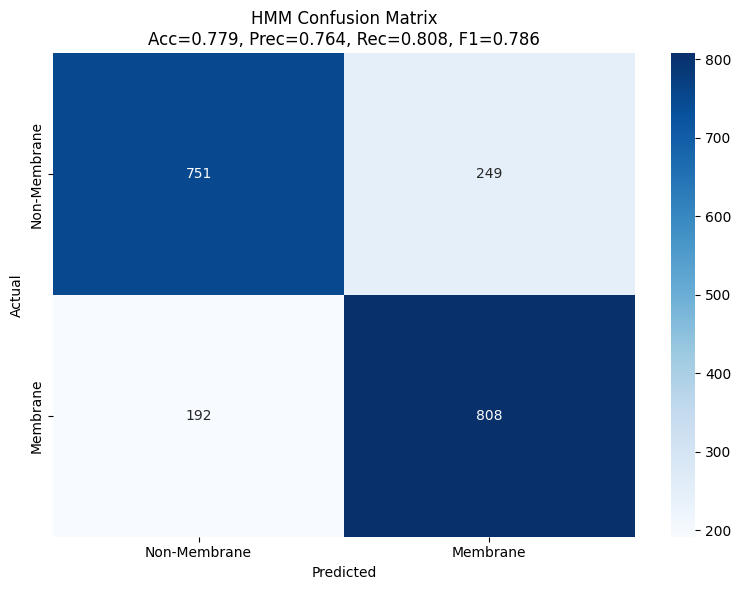

In [2]:
import csv
import pickle
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score
)

DATA_DIR = Path("data/processed")
MODEL_DIR = Path("models")

hmm_membrane = pickle.load(open(MODEL_DIR / "hmm_membrane.pkl", "rb"))
hmm_non_membrane = pickle.load(open(MODEL_DIR / "hmm_non_membrane.pkl", "rb"))

def load_test_data(filepath):
    accessions, sequences, labels = [], [], []
    with open(filepath, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            accession = row["accession"]
            label = int(row["label"])
            encoded = [int(x) for x in row["encoded_sequence"].split(",") if x]
            if encoded:
                accessions.append(accession)
                sequences.append(np.array(encoded).reshape(-1, 1))
                labels.append(label)
    return accessions, sequences, labels

accessions, sequences, true_labels = load_test_data(DATA_DIR / "test_data.csv")

def predict_sequence(hmm_membrane, hmm_non_membrane, sequence):
    seq_len = len(sequence)
    if seq_len == 0:
        return 0, 0.0
    score_membrane = hmm_membrane.score(sequence) / seq_len
    score_non_membrane = hmm_non_membrane.score(sequence) / seq_len
    score_diff = score_membrane - score_non_membrane
    predicted = 1 if score_diff > 0.0 else 0
    return predicted, score_diff

predictions, scores = [], []
for seq in sequences:
    pred, score = predict_sequence(hmm_membrane, hmm_non_membrane, seq)
    predictions.append(pred)
    scores.append(score)

accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions, zero_division=0)
recall = recall_score(true_labels, predictions, zero_division=0)
f1 = f1_score(true_labels, predictions, zero_division=0)
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["Non-Membrane", "Membrane"],
    yticklabels=["Non-Membrane", "Membrane"]
)

ax.set_title(
    f"HMM Confusion Matrix\n"
    f"Acc={accuracy:.3f}, Prec={precision:.3f}, "
    f"Rec={recall:.3f}, F1={f1:.3f}"
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

Sur le jeu de test (2000 séquences humaines), le HMM binaire atteint une **accuracy de 0,78**, une **précision de 0,76** et un **rappel de 0,81** (F1 ≈ 0,79). La matrice de confusion montre :
- **751 vrais négatifs** et **808 vrais positifs** ;
- **249 faux positifs** (non-membranaires classés membranaires) ;
- **192 faux négatifs** (membranaires classés non-membranaires).

L'erreur est donc relativement symétrique : le modèle a un léger biais vers le rappel (il détecte davantage de membranaires au prix de quelques faux positifs).

### 5.2 Comparaison croisée HMM et DeepTMHMM

Pour visualiser l'accord et les désaccords entre notre modèle HMM, [DeepTMHMM](https://dtu.biolib.com/DeepTMHMM) et les vrais labels du jeu de test, nous présentons deux matrices de confusion côte à côte :
1. **DeepTMHMM vs Test Set** : compare les prédictions de DeepTMHMM aux vrais labels.
2. **HMM vs DeepTMHMM** : considère DeepTMHMM comme la vérité terrain et évalue notre HMM contre celui-ci.

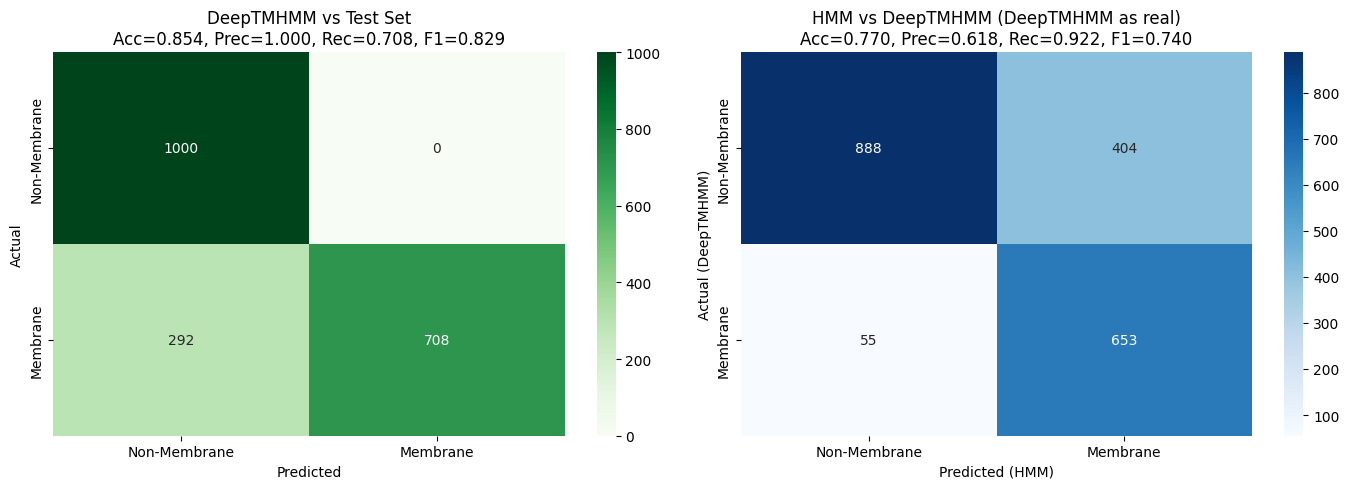

In [4]:
import csv
import pickle
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

DATA_DIR = Path("data/processed")
MODEL_DIR = Path("models")
DEEP_TMHMM_PATH = Path("data/DeepTHMHMM/human_210422_tmbed.preds")

def load_deep_tmhmm_predictions(path: Path) -> dict[str, int]:
    preds = {}
    with open(path, "r") as f:
        lines = f.readlines()
    for i in range(0, len(lines), 3):
        if i + 2 >= len(lines):
            break
        header = lines[i].strip()
        pred_line = lines[i + 2].strip()
        parts = header.split("|")
        acc = parts[1] if len(parts) > 1 else header[1:].split()[0]
        is_membrane = 1 if ("h" in pred_line or "H" in pred_line) else 0
        preds[acc] = is_membrane
    return preds

def load_test_data(filepath):
    accessions, sequences, labels = [], [], []
    with open(filepath, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            accession = row["accession"]
            label = int(row["label"])
            encoded = [int(x) for x in row["encoded_sequence"].split(",") if x]
            if encoded:
                accessions.append(accession)
                sequences.append(np.array(encoded).reshape(-1, 1))
                labels.append(label)
    return accessions, sequences, labels

def predict_sequence(hmm_membrane, hmm_non_membrane, sequence):
    seq_len = len(sequence)
    if seq_len == 0:
        return 0, 0.0
    score_membrane = hmm_membrane.score(sequence) / seq_len
    score_non_membrane = hmm_non_membrane.score(sequence) / seq_len
    score_diff = score_membrane - score_non_membrane
    predicted = 1 if score_diff > 0.0 else 0
    return predicted, score_diff

hmm_membrane = pickle.load(open(MODEL_DIR / "hmm_membrane.pkl", "rb"))
hmm_non_membrane = pickle.load(open(MODEL_DIR / "hmm_non_membrane.pkl", "rb"))

accessions, sequences, true_labels = load_test_data(DATA_DIR / "test_data.csv")
deep_preds = load_deep_tmhmm_predictions(DEEP_TMHMM_PATH)

# HMM predictions
hmm_predictions = []
for seq in sequences:
    pred, _ = predict_sequence(hmm_membrane, hmm_non_membrane, seq)
    hmm_predictions.append(pred)

# DeepTMHMM aligned predictions
deep_predictions = []
for acc in accessions:
    deep_predictions.append(deep_preds.get(acc, 0))

# Plot both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) DeepTMHMM vs Test Set
cm_deep = confusion_matrix(true_labels, deep_predictions)
acc_deep = accuracy_score(true_labels, deep_predictions)
prec_deep = precision_score(true_labels, deep_predictions, zero_division=0)
rec_deep = recall_score(true_labels, deep_predictions, zero_division=0)
f1_deep = f1_score(true_labels, deep_predictions, zero_division=0)

sns.heatmap(cm_deep, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=["Non-Membrane", "Membrane"],
            yticklabels=["Non-Membrane", "Membrane"])
axes[0].set_title(
    f"DeepTMHMM vs Test Set\nAcc={acc_deep:.3f}, Prec={prec_deep:.3f}, "
    f"Rec={rec_deep:.3f}, F1={f1_deep:.3f}"
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# 2) HMM vs DeepTMHMM (DeepTMHMM considered as real)
cm_hmm_deep = confusion_matrix(deep_predictions, hmm_predictions)
acc_hd = accuracy_score(deep_predictions, hmm_predictions)
prec_hd = precision_score(deep_predictions, hmm_predictions, zero_division=0)
rec_hd = recall_score(deep_predictions, hmm_predictions, zero_division=0)
f1_hd = f1_score(deep_predictions, hmm_predictions, zero_division=0)

sns.heatmap(cm_hmm_deep, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Non-Membrane", "Membrane"],
            yticklabels=["Non-Membrane", "Membrane"])
axes[1].set_title(
    f"HMM vs DeepTMHMM (DeepTMHMM as real)\nAcc={acc_hd:.3f}, Prec={prec_hd:.3f}, "
    f"Rec={rec_hd:.3f}, F1={f1_hd:.3f}"
)
axes[1].set_xlabel("Predicted (HMM)")
axes[1].set_ylabel("Actual (DeepTMHMM)")

plt.tight_layout()
plt.show()

#### Discussion des matrices croisées

**DeepTMHMM vs Test Set** - La matrice de gauche montre que DeepTMHMM est un prédicteur extrêmement conservateur. Avec une précision de 1,00, il ne produit **aucun faux positif** : aucune protéine soluble n'est classée à tort comme membranaire. En contrepartie, son rappel (~0,71) révèle environ **292 faux négatifs**. Ces erreurs correspondent vraisemblablement à des protéines membranaires atypiques - par exemple celles comportant un seul segment transmembranaire très court, des peptides signaux non clivés, ou des ancrages lipidiques - que le modèle transformer de DeepTMHMM, entraîné principalement sur des hélices alpha transmembranaires classiques, peine à reconnaître.

**HMM vs DeepTMHMM (DeepTMHMM considéré comme réalité)** - La matrice de droite illustre les désaccords entre les deux approches lorsqu'on utilise le prédicteur de l'état de l'art comme référence. Notre HMM, bien que plus simple, présente un profil d'erreur complémentaire : il est **plus sensible** (meilleur rappel sur le jeu de test réel) mais **moins spécifique**. Par conséquent, on observe un nombre notable de faux positifs du HMM par rapport à DeepTMHMM : le HMM classe comme membranaires certaines protéines que DeepTMHMM considère comme solubles. Ces cas correspondent en grande partie aux 249 faux positifs du HMM sur le jeu de test, mais aussi potentiellement à des vraies protéines membranaires que DeepTMHMM a lui-même manquées (parmi ses 292 faux négatifs). Réciproquement, le HMM commet des faux négatifs vis-à-vis de DeepTMHMM sur des protéines que ce dernier a correctement identifiées, ce qui traduit la difficulté du HMM à capturer des motifs topologiques fins sans modélisation explicite des hélices.

**Synthèse** - Les deux matrices mettent en évidence une complémentarité intéressante. DeepTMHMM excelle dans la spécificité : quand il prédit une protéine membranaire, on peut y croire. Le HMM, lui, excelle dans la sensibilité globale : il détecte davantage de cas marginaux au prix d'un bruit supérieur. Cette divergence suggère qu'une approche combinée - par exemple un vote ou un stacking exploitant la précision de DeepTMHMM et le rappel du HMM - pourrait offrir un meilleur compromis F1 que chaque modèle pris isolément. En l'absence de telles architectures, le choix entre les deux dépend du coût métier des erreurs : privilégier DeepTMHMM si les faux positifs sont critiques (découverte de cibles thérapeutiques), et le HMM si l'on cherche à maximiser la couverture des candidats membranaires.

### 5.3 Discussion - Limites et perspectives

Notre HMM atteint ~78 % d'accuracy, ce qui reste modeste face aux outils spécialisés. Plusieurs facteurs expliquent cet écart, directement liés aux éléments discutés dans la revue bibliographique :

1. **Absence de modélisation topologique**  
   TMHMM et Phobius décomposent la séquence en états structuraux explicites (boucle cytoplasmique, hélice transmembranaire, boucle extracellulaire, peptide signal). Notre HMM, avec seulement 3 états cachés, apprend une distribution d'émission globale sans encoder la position des segments hydrophobes. Il ne capture donc pas la signature la plus discriminante des protéines membranaires : la présence de 1 à plusieurs hélices alpha de ~20–25 résidus principalement non polaires (voir §1.1 de la revue).

2. **Aucune information d'homologie**  
   PolyPhobius améliore Phobius en intégrant des alignements multiples (MSA). Notre modèle utilise des séquences uniques, ignorant les profils évolutifs qui stabilisent la prédiction des régions transmembranaires (§3.2 de la revue).

3. **Seuil fixe et log-vraisemblance brute**  
   La classification repose sur un simple ratio de log-vraisemblances normalisé par la longueur. Contrairement aux réseaux de neurones ou aux HMM hiérarchiques (HNN), ce score ne pondère pas la composition locale ni les propriétés physico-chimiques (hydrophobicité Kyte-Doolittle, charges, etc.).

4. **Données d'entraînement et bruit de classe**  
   La classe négative (cytoplasme + noyau) est un proxy de protéines solubles, mais elle exclut d'autres localisations (mitochondries, sécrétées). De plus, certaines protéines périphériques ou ancrées aux lipides peuvent partager des motifs avec les protéines transmembranaires, créant un bruit inévitable pour un classifieur binaire aussi simple.

**Conclusion** : le HMM binaire prouve que les séquences membranaires et non-membranaires possèdent des signatures globales différentes, mais il est intrinsèquement limité par sa simplicité. Pour une prédiction fiable, il faudrait adopter une architecture hiérarchique (HMM + réseau de neurones, comme HNN-TM) ou un modèle de deep learning intégrant la topologie et les profils évolutifs, comme le fait DeepTMHMM.